In [1]:
import numpy as np
import wfdb #libreria per usare segnali database mit-bih
import scipy.signal as signal
import matplotlib.pyplot as plt
from scipy.signal import iirnotch, filtfilt
import pandas as pd
from PIL import Image
import cv2

import torch
import torchvision.models as models
import torchvision.transforms as transforms

from sklearn.decomposition import PCA

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from tensorflow.keras import backend as K # fornisce una serie di funzioni per manipolare i tensori
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Dropout
from keras.callbacks import EarlyStopping
from keras.losses import categorical_crossentropy
from keras.metrics import categorical_accuracy

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials


# Cardiac arrhythmia detection using deep learning 

Studio ECG, misurazione degli impulsi elettrici del cuore. Aritmia è l'aterazione del ritmo del cuore.

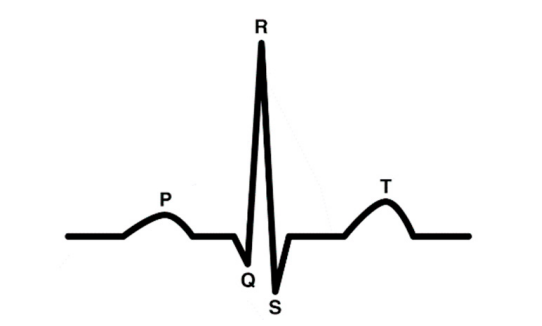

Obiettivo classificare dalle tracce di ECG:
- Battiti normali
- Battiti artificiali, generati da pacemaker
- Battiti di paziente affetto da blocco di branca destra (RBBB)


Dati: MIT-BIH Arrhytmia database (2017); ECG della durata di 30 minuti campionati a frequenza di 360 Hz. Le tracce di ECG sono state classificate da medici.


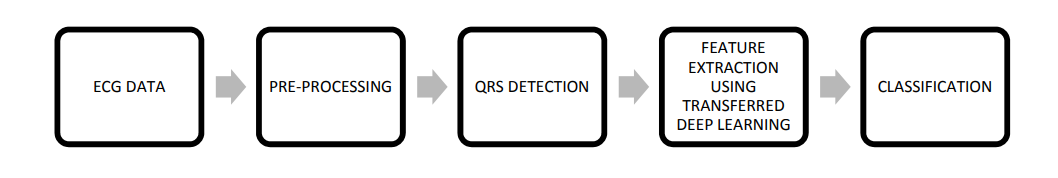

In [2]:
def get_ml_ii_signal(file_path):
    """
    Estrae il segnale del canale 'MLII' dal file specificato per il primo minuto di registrazione.

    Parameters:
        file_path (str): Il percorso del file .dat (incluso il nome del file senza l'estensione .dat).

    Returns:
        numpy.ndarray: Il segnale del canale 'MLII' per il primo minuto di registrazione.
    """
    # Caricamento ECG
    record = wfdb.rdrecord(file_path)  

    sampling_frequency = record.fs
    samples_per_minute = int(sampling_frequency * 60)
    samples_start = int(sampling_frequency * 60 * 5)
    #  del canale 'MLII'
    channel_index = record.sig_name.index('MLII')
    # # Estrazione del canale 'MLII'
    # ml_ii_signal = record.p_signal[samples_start:samples_start+samples_per_minute , channel_index]
    ml_ii_signal = record.p_signal[:samples_per_minute , channel_index]
    # ml_ii_signal = record.p_signal[: , channel_index]

    return ml_ii_signal


def remove_mean(signal):
    """
    Rimuove la media dal segnale.

    Parameters:
        signal (numpy.ndarray): Il segnale da cui rimuovere la media.

    Returns:
        numpy.ndarray: Il segnale con la media rimossa.
    """
    mean_value = np.mean(signal)
    detrended_signal = signal - mean_value
    return detrended_signal


def moving_average_filter(signal, window_size):
    return np.convolve(signal, np.ones(window_size)/window_size, mode='same')


def derivative_filter(signal):
    return np.diff(signal, prepend=signal[0])


def apply_notch_filter(signal, fs, freq=60.0, Q=30.0):
    """
    Applica un filtro notch per rimuovere una specifica frequenza e le sue armoniche.

    Parameters:
        signal (numpy.ndarray): Il segnale da filtrare.
        fs (float): La frequenza di campionamento del segnale.
        freq (float): La frequenza da rimuovere (default è 60 Hz).
        Q (float): Fattore di qualità del filtro (default è 30).

    Returns:
        numpy.ndarray: Il segnale filtrato.
    """
    harmonics = int(fs // (2 * freq))  # Numero di armoniche fino alla frequenza di Nyquist
    filtered_signal = signal
    for i in range(1, harmonics + 1):
        f0 = i * freq
        b, a = iirnotch(f0, Q, fs)
        filtered_signal = filtfilt(b, a, filtered_signal)
    return filtered_signal


## ECG Data Acquisition


Prendo sei tracce di ECG, due per ciascuna tipologia di battiti, una per il set di train e una per il set di test. Estraggo un solo minuto di registrazione.


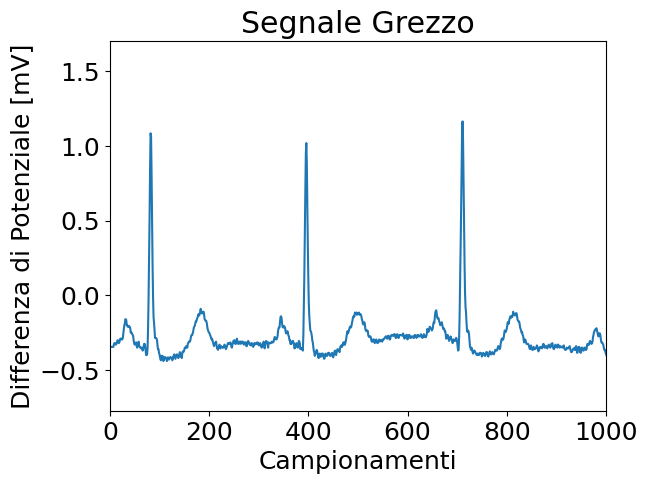

In [3]:
#carico dati un minuto di ecg per train e test per le tre diverse classi
path_train_N = '100'
path_train_RBBB = '118' 
path_train_pace = '217'

path_test_N = '101'
path_test_RBBB = '231' 
path_test_pace = '107'

train_N_signal = get_ml_ii_signal(path_train_N)
train_RBBB_signal = get_ml_ii_signal(path_train_RBBB)
train_pace_signal = get_ml_ii_signal(path_train_pace)

test_N_signal = get_ml_ii_signal(path_test_N)
test_RBBB_signal = get_ml_ii_signal(path_test_RBBB)
test_pace_signal = get_ml_ii_signal(path_test_pace)

plt.rcParams.update({'font.size': 18})


plt.plot(test_N_signal)
plt.xlim([0,1000])
plt.title('Segnale Grezzo')
plt.xlabel('Campionamenti')
plt.ylabel('Differenza di Potenziale [mV]')
plt.show()

## Signal Pre-processing 


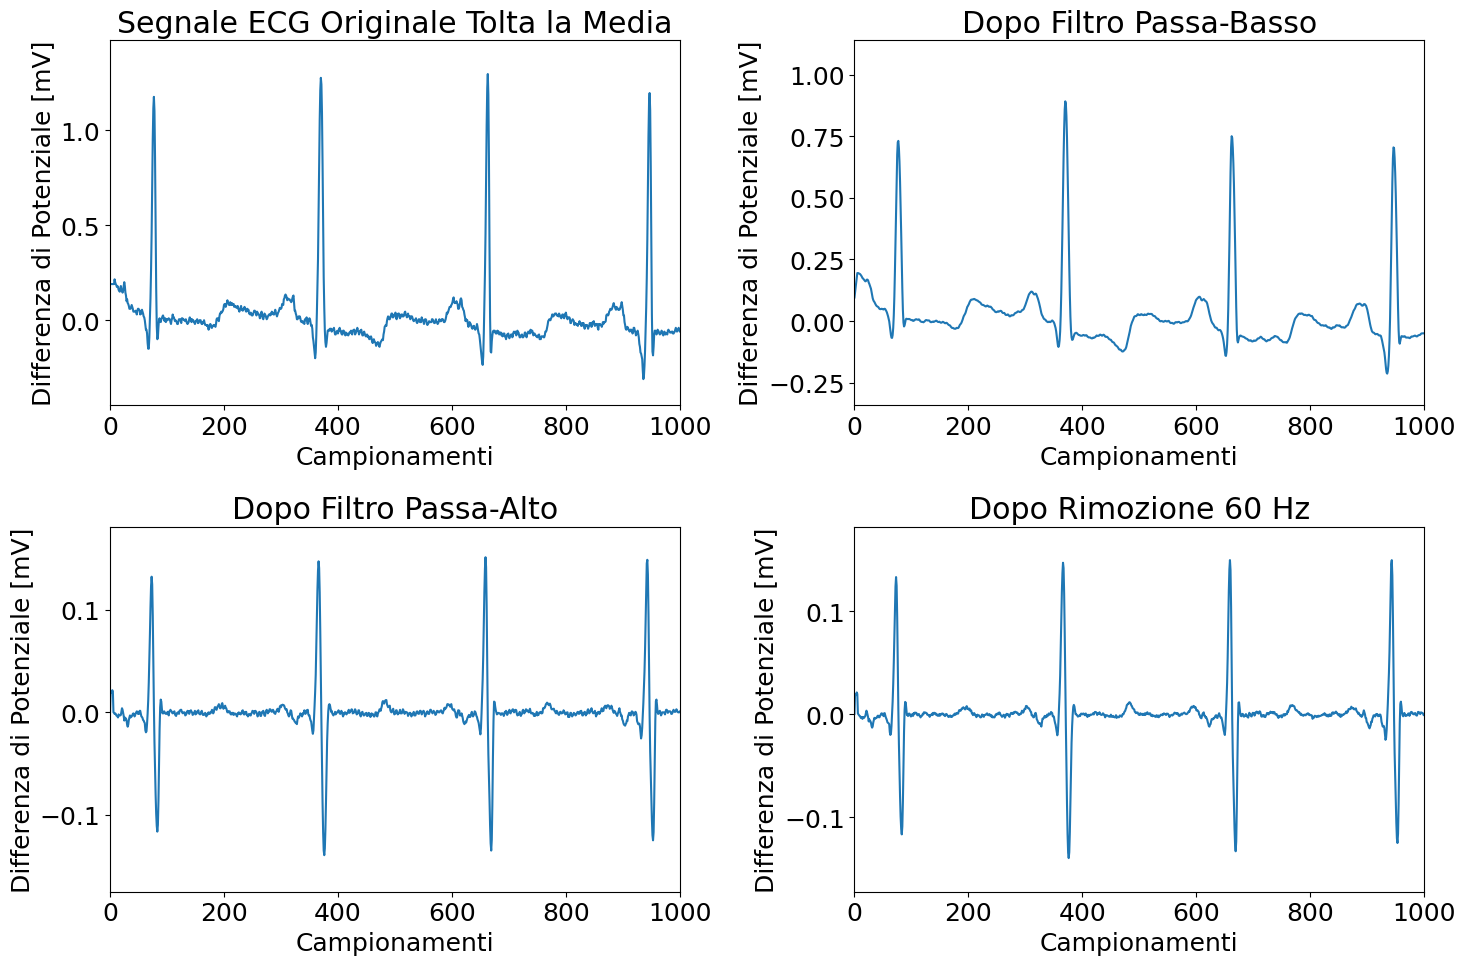

In [4]:
sampling_frequency = 360

#rimuovo la media del segnale, per togliere la componente DC 
detrended_train_N_signal = remove_mean(train_N_signal)
detrended_train_RBBB_signal = remove_mean(train_RBBB_signal)
detrended_train_pace_signal = remove_mean(train_pace_signal)

detrended_test_N_signal = remove_mean(test_N_signal)
detrended_test_RBBB_signal = remove_mean(test_RBBB_signal)
detrended_test_pace_signal = remove_mean(test_pace_signal)

# ruovo rumore ad alta frequenza con filtro a media mobile di 10 punti
#rumore principalmente derivato dalle contrazioni muscolari
filtered_signal_low_freq_N_train = moving_average_filter(detrended_train_N_signal, 10)
filtered_signal_low_freq_RBBB_train = moving_average_filter(detrended_train_RBBB_signal, 10)
filtered_signal_low_freq_pace_train = moving_average_filter(detrended_train_pace_signal, 10)

filtered_signal_low_freq_N_test = moving_average_filter(detrended_test_N_signal, 10)
filtered_signal_low_freq_RBBB_test = moving_average_filter(detrended_test_RBBB_signal, 10)
filtered_signal_low_freq_pace_test = moving_average_filter(detrended_test_pace_signal, 10)

# rimuovo rumore a bassa frequenza con filtro basato sulla derivata
#rumore principalmente derivato dal respiro
filtered_signal_high_freq_N_train = derivative_filter(filtered_signal_low_freq_N_train)
filtered_signal_high_freq_RBBB_train = derivative_filter(filtered_signal_low_freq_RBBB_train)
filtered_signal_high_freq_pace_train = derivative_filter(filtered_signal_low_freq_pace_train)

filtered_signal_high_freq_N_test = derivative_filter(filtered_signal_low_freq_N_test)
filtered_signal_high_freq_RBBB_test = derivative_filter(filtered_signal_low_freq_RBBB_test)
filtered_signal_high_freq_pace_test = derivative_filter(filtered_signal_low_freq_pace_test)

# rimuovo frequenze 60 Hz e sue armoniche
# rumore derivato da interferenza linea elettrica
clean_signal_N_train = apply_notch_filter(filtered_signal_high_freq_N_train, sampling_frequency)
clean_signal_RBBB_train = apply_notch_filter(filtered_signal_high_freq_RBBB_train, sampling_frequency)
clean_signal_pace_train = apply_notch_filter(filtered_signal_high_freq_pace_train, sampling_frequency)

clean_signal_N_test = apply_notch_filter(filtered_signal_high_freq_N_test, sampling_frequency)
clean_signal_RBBB_test = apply_notch_filter(filtered_signal_high_freq_RBBB_test, sampling_frequency)
clean_signal_pace_test = apply_notch_filter(filtered_signal_high_freq_pace_test, sampling_frequency)




# Plot del segnale ECG dopo la rimozione della media, dopo aver filtrato le alte frequenze, dopo aver filtrato le basse frequenze, dopo aver filtrato
# le frequenze a 60 Hz ( e sue armoniche)
# tutti i segnali fanno riferimento al segnale ECG originario di test_N
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Segnale ECG Originale meno media
axes[0, 0].plot(detrended_train_N_signal)
axes[0, 0].set_title('Segnale ECG Originale Tolta la Media')
axes[0, 0].set_xlim([0, 1000])
axes[0,0].set_xlabel('Campionamenti')
axes[0,0].set_ylabel('Differenza di Potenziale [mV]')

# Dopo Filtro Passa-Basso
axes[0, 1].plot(filtered_signal_low_freq_N_train)
axes[0, 1].set_title('Dopo Filtro Passa-Basso')
axes[0, 1].set_xlim([0, 1000])
axes[0,1].set_xlabel('Campionamenti')
axes[0,1].set_ylabel('Differenza di Potenziale [mV]')


# Dopo Filtro Passa-Alto
axes[1, 0].plot(filtered_signal_high_freq_N_train)
axes[1, 0].set_title('Dopo Filtro Passa-Alto')
axes[1, 0].set_xlim([0, 1000])
axes[1,0].set_xlabel('Campionamenti')
axes[1,0].set_ylabel('Differenza di Potenziale [mV]')

# Dopo Rimozione 60 Hz
axes[1, 1].plot(clean_signal_N_train)
axes[1, 1].set_title('Dopo Rimozione 60 Hz')
axes[1, 1].set_xlim([0, 1000])
axes[1,1].set_xlabel('Campionamenti')
axes[1,1].set_ylabel('Differenza di Potenziale [mV]')

plt.tight_layout()
plt.show()


## QRS detection 


Con l'algoritmo di Pan-Tompkins. https://github.com/antimattercorrade/Pan_Tompkins_QRS_Detection

In [5]:
class Pan_Tompkins_QRS():
  
  def band_pass_filter(self,signal):
    '''
    Band Pass Filter
    :param signal: input signal
    :return: prcoessed signal

    Methodology/Explaination:
    Bandpass filter is used to attenuate the noise in the input signal.
    To acheive a passband of 5-15 Hz, the input signal is first passed 
    through a low pass filter having a cutoff frequency of 11 Hz and then
    through a high pass filter with a cutoff frequency of 5 Hz, thus
    achieving the required thresholds. 

    The low pass filter has the recursive equation:
      y(nT) = 2y(nT - T) - y(nT - 2T) + x(nT) - 2x(nT - 6T) + x(nT - 12T)

    The high pass filter has the recursive equation:
      y(nT) = 32x(nT - 16T) - y(nT - T) - x(nT) + x(nT - 32T)
    '''

    # Initialize result
    result = None

    # Create a copy of the input signal
    sig = signal.copy()
	
    # Apply the low pass filter using the equation given
    for index in range(len(signal)):
      sig[index] = signal[index]

      if (index >= 1):
        sig[index] += 2*sig[index-1]

      if (index >= 2):
        sig[index] -= sig[index-2]

      if (index >= 6):
        sig[index] -= 2*signal[index-6]

      if (index >= 12):
        sig[index] += signal[index-12] 
	
    # Copy the result of the low pass filter
    result = sig.copy()

    # Apply the high pass filter using the equation given
    for index in range(len(signal)):
      result[index] = -1*sig[index]

      if (index >= 1):
        result[index] -= result[index-1]

      if (index >= 16):
        result[index] += 32*sig[index-16]

      if (index >= 32):
        result[index] += sig[index-32]

    # Normalize the result from the high pass filter
    max_val = max(max(result),-min(result))
    result = result/max_val

    return result

  def derivative(self,signal):
    '''
    Derivative Filter 
    :param signal: input signal
    :return: prcoessed signal

    Methodology/Explaination:
    The derivative of the input signal is taken to obtain the
    information of the slope of the signal. Thus, the rate of change
    of input is obtain in this step of the algorithm.

    The derivative filter has the recursive equation:
      y(nT) = [-x(nT - 2T) - 2x(nT - T) + 2x(nT + T) + x(nT + 2T)]/(8T)
    '''

    # Initialize result
    result = signal.copy()

    # Apply the derivative filter using the equation given
    for index in range(len(signal)):
      result[index] = 0

      if (index >= 1):
        result[index] -= 2*signal[index-1]

      if (index >= 2):
        result[index] -= signal[index-2]

      if (index >= 2 and index <= len(signal)-2):
        result[index] += 2*signal[index+1]

      if (index >= 2 and index <= len(signal)-3):
        result[index] += signal[index+2]

      result[index] = (result[index]*360)/8

    return result

  def squaring(self,signal):
    '''
    Squaring the Signal
    :param signal: input signal
    :return: prcoessed signal

    Methodology/Explaination:
    The squaring process is used to intensify the slope of the
    frequency response curve obtained in the derivative step. This
    step helps in restricting false positives which may be caused
    by T waves in the input signal.

    The squaring filter has the recursive equation:
      y(nT) = [x(nT)]^2
    '''

    # Initialize result
    result = signal.copy()

    # Apply the squaring using the equation given
    for index in range(len(signal)):
      result[index] = signal[index]**2

    return result    

  def moving_window_integration(self,signal):
    '''
    Moving Window Integrator
    :param signal: input signal
    :return: prcoessed signal

    Methodology/Explaination:
    The moving window integration process is done to obtain
    information about both the slope and width of the QRS complex.
    A window size of 0.15*(sample frequency) is used for more
    accurate results.

    The moving window integration has the recursive equation:
      y(nT) = [y(nT - (N-1)T) + x(nT - (N-2)T) + ... + x(nT)]/N

      where N is the number of samples in the width of integration
      window.
    '''

    # Initialize result and window size for integration
    result = signal.copy()
    win_size = round(0.150 * 360)
    sum = 0

    # Calculate the sum for the first N terms
    for j in range(win_size):
      sum += signal[j]/win_size
      result[j] = sum
    
    # Apply the moving window integration using the equation given
    for index in range(win_size,len(signal)):  
      sum += signal[index]/win_size
      sum -= signal[index-win_size]/win_size
      result[index] = sum

    return result

  def solve(self,signal):
    '''
    Solver, Combines all the above functions
    :param signal: input signal
    :return: prcoessed signal

    Methodology/Explaination:
    The peak detection algorithm works on the moving window and bandpass
    filtered signal. So the input signal is first bandpassed, then the
    output of the bandpass filter is given to the derivative function and
    the result is squared. Finally the output of the squaring function
    is given to the moving window integration function and returned. 
    '''

    # Convert the input signal into numpy array
    input_signal = signal.iloc[:,1].to_numpy()

    # Bandpass Filter
    global bpass
    bpass = self.band_pass_filter(input_signal.copy())

    # Derivative Function
    global der
    der = self.derivative(bpass.copy())

    # Squaring Function
    global sqr
    sqr = self.squaring(der.copy())

    # Moving Window Integration Function
    global mwin
    mwin = self.moving_window_integration(sqr.copy())

    return mwin

# Importing Libraries
from scipy import signal as sg

class heart_rate():

  def __init__(self,signal,samp_freq):
    '''
    Initialize Variables
    :param signal: input signal
    :param samp_freq: sample frequency of input signal
    '''

    # Initialize variables
    self.RR1, self.RR2, self.probable_peaks, self.r_locs, self.peaks, self.result = ([] for i in range(6))
    self.SPKI, self.NPKI, self.Threshold_I1, self.Threshold_I2, self.SPKF, self.NPKF, self.Threshold_F1, self.Threshold_F2 = (0 for i in range(8))

    self.T_wave = False          
    self.m_win = mwin
    self.b_pass = bpass
    self.samp_freq = samp_freq
    self.signal = signal
    self.win_150ms = round(0.15*self.samp_freq)

    self.RR_Low_Limit = 0
    self.RR_High_Limit = 0
    self.RR_Missed_Limit = 0
    self.RR_Average1 = 0


  def approx_peak(self):
    '''
    Approximate peak locations
    '''   

    # FFT convolution
    slopes = sg.fftconvolve(self.m_win, np.full((25,), 1) / 25, mode='same')

    # Finding approximate peak locations
    for i in range(round(0.5*self.samp_freq) + 1,len(slopes)-1):
        if (slopes[i] > slopes[i-1]) and (slopes[i+1] < slopes[i]):
            self.peaks.append(i)  


  def adjust_rr_interval(self,ind):
    '''
    Adjust RR Interval and Limits
    :param ind: current index in peaks array
    '''

    # Finding the eight most recent RR intervals
    self.RR1 = np.diff(self.peaks[max(0,ind - 8) : ind + 1])/self.samp_freq   

    # Calculating RR Averages
    self.RR_Average1 = np.mean(self.RR1)
    RR_Average2 = self.RR_Average1
      
    # Finding the eight most recent RR intervals lying between RR Low Limit and RR High Limit  
    if (ind >= 8):
        for i in range(0, 8):
            if (self.RR_Low_Limit < self.RR1[i] < self.RR_High_Limit): 
                self.RR2.append(self.RR1[i])

                if (len(self.RR2) > 8):
                    self.RR2.remove(self.RR2[0])
                    RR_Average2 = np.mean(self.RR2)    

    # Adjusting the RR Low Limit and RR High Limit
    if (len(self.RR2) > 7 or ind < 8):
        self.RR_Low_Limit = 0.92 * RR_Average2        
        self.RR_High_Limit = 1.16 * RR_Average2
        self.RR_Missed_Limit = 1.66 * RR_Average2


  def searchback(self,peak_val,RRn,sb_win):
      '''
      Searchback
      :param peak_val: peak location in consideration
      :param RRn: the most recent RR interval
      :param sb_win: searchback window
      '''

      # Check if the most recent RR interval is greater than the RR Missed Limit
      if (RRn > self.RR_Missed_Limit):
          # Initialize a window to searchback  
          win_rr = self.m_win[peak_val - sb_win + 1 : peak_val + 1] 

          # Find the x locations inside the window having y values greater than Threshold I1             
          coord = np.asarray(win_rr > self.Threshold_I1).nonzero()[0]

          # Find the x location of the max peak value in the search window
          if (len(coord) > 0):
              for pos in coord:
                  if (win_rr[pos] == max(win_rr[coord])):
                      x_max = pos
                      break
          else:
            x_max = None
 
          # If the max peak value is found
          if (x_max is not None):   
            # Update the thresholds corresponding to moving window integration
            self.SPKI = 0.25 * self.m_win[x_max] + 0.75 * self.SPKI                         
            self.Threshold_I1 = self.NPKI + 0.25 * (self.SPKI - self.NPKI)
            self.Threshold_I2 = 0.5 * self.Threshold_I1         

            # Initialize a window to searchback 
            win_rr = self.b_pass[x_max - self.win_150ms: min(len(self.b_pass) -1, x_max)]  

            # Find the x locations inside the window having y values greater than Threshold F1                   
            coord = np.asarray(win_rr > self.Threshold_F1).nonzero()[0]

            # Find the x location of the max peak value in the search window
            if (len(coord) > 0):
              for pos in coord:
                  if (win_rr[pos] == max(win_rr[coord])):
                      r_max = pos
                      break
            else:
              r_max = None

            # If the max peak value is found
            if (r_max is not None):
              # Update the thresholds corresponding to bandpass filter
              if self.b_pass[r_max] > self.Threshold_F2:                                                        
                  self.SPKF = 0.25 * self.b_pass[r_max] + 0.75 * self.SPKF                            
                  self.Threshold_F1 = self.NPKF + 0.25 * (self.SPKF - self.NPKF)
                  self.Threshold_F2 = 0.5 * self.Threshold_F1      

                  # Append the probable R peak location                      
                  self.r_locs.append(r_max)                                                


  def find_t_wave(self,peak_val,RRn,ind,prev_ind):
    '''
    T Wave Identification
    :param peak_val: peak location in consideration
    :param RRn: the most recent RR interval
    :param ind: current index in peaks array
    :param prev_ind: previous index in peaks array
    '''

    if (self.m_win[peak_val] >= self.Threshold_I1): 
        if (ind > 0 and 0.20 < RRn < 0.36):
          # Find the slope of current and last waveform detected        
          curr_slope = max(np.diff(self.m_win[peak_val - round(self.win_150ms/2) : peak_val + 1]))
          last_slope = max(np.diff(self.m_win[self.peaks[prev_ind] - round(self.win_150ms/2) : self.peaks[prev_ind] + 1]))
          
          # If current waveform slope is less than half of last waveform slope
          if (curr_slope < 0.5*last_slope):  
              # T Wave is found and update noise threshold                      
              self.T_wave = True                             
              self.NPKI = 0.125 * self.m_win[peak_val] + 0.875 * self.NPKI 

        if (not self.T_wave):
            # T Wave is not found and update signal thresholds
            if (self.probable_peaks[ind] > self.Threshold_F1):   
                self.SPKI = 0.125 * self.m_win[peak_val]  + 0.875 * self.SPKI                                         
                self.SPKF = 0.125 * self.b_pass[ind] + 0.875 * self.SPKF 

                # Append the probable R peak location
                self.r_locs.append(self.probable_peaks[ind])  

            else:
                self.SPKI = 0.125 * self.m_win[peak_val]  + 0.875 * self.SPKI
                self.NPKF = 0.125 * self.b_pass[ind] + 0.875 * self.NPKF                   

    # Update noise thresholds
    elif (self.m_win[peak_val] < self.Threshold_I1) or (self.Threshold_I1 < self.m_win[peak_val] < self.Threshold_I2):
        self.NPKI = 0.125 * self.m_win[peak_val]  + 0.875 * self.NPKI  
        self.NPKF = 0.125 * self.b_pass[ind] + 0.875 * self.NPKF


  def adjust_thresholds(self,peak_val,ind):
    '''
    Adjust Noise and Signal Thresholds During Learning Phase
    :param peak_val: peak location in consideration
    :param ind: current index in peaks array
    '''

    if (self.m_win[peak_val] >= self.Threshold_I1): 
        # Update signal threshold
        self.SPKI = 0.125 * self.m_win[peak_val]  + 0.875 * self.SPKI

        if (self.probable_peaks[ind] > self.Threshold_F1):                                            
            self.SPKF = 0.125 * self.b_pass[ind] + 0.875 * self.SPKF 

            # Append the probable R peak location
            self.r_locs.append(self.probable_peaks[ind])  

        else:
            # Update noise threshold
            self.NPKF = 0.125 * self.b_pass[ind] + 0.875 * self.NPKF                                    
        
    # Update noise thresholds    
    elif (self.m_win[peak_val] < self.Threshold_I2) or (self.Threshold_I2 < self.m_win[peak_val] < self.Threshold_I1):
        self.NPKI = 0.125 * self.m_win[peak_val]  + 0.875 * self.NPKI  
        self.NPKF = 0.125 * self.b_pass[ind] + 0.875 * self.NPKF


  def update_thresholds(self):
    '''
    Update Noise and Signal Thresholds for next iteration
    '''

    self.Threshold_I1 = self.NPKI + 0.25 * (self.SPKI - self.NPKI)
    self.Threshold_F1 = self.NPKF + 0.25 * (self.SPKF - self.NPKF)
    self.Threshold_I2 = 0.5 * self.Threshold_I1 
    self.Threshold_F2 = 0.5 * self.Threshold_F1
    self.T_wave = False 


  def ecg_searchback(self):
    '''
    Searchback in ECG signal to increase efficiency
    '''

    # Filter the unique R peak locations
    self.r_locs = np.unique(np.array(self.r_locs).astype(int))

    # Initialize a window to searchback
    win_200ms = round(0.2*self.samp_freq)
   
    for r_val in self.r_locs:
        coord = np.arange(r_val - win_200ms, min(len(self.signal), r_val + win_200ms + 1), 1)

        # Find the x location of the max peak value
        if (len(coord) > 0):
          for pos in coord:
              if (self.signal[pos] == max(self.signal[coord])):
                  x_max = pos
                  break
        else:
          x_max = None

        # Append the peak location
        if (x_max is not None):   
          self.result.append(x_max)


  def find_r_peaks(self):
    '''
    R Peak Detection
    '''

    # Find approximate peak locations
    self.approx_peak()

    # Iterate over possible peak locations
    for ind in range(len(self.peaks)):

        # Initialize the search window for peak detection
        peak_val = self.peaks[ind]
        win_300ms = np.arange(max(0, self.peaks[ind] - self.win_150ms), min(self.peaks[ind] + self.win_150ms, len(self.b_pass)-1), 1)
        max_val = max(self.b_pass[win_300ms], default = 0)

        # Find the x location of the max peak value
        if (max_val != 0):        
          x_coord = np.asarray(self.b_pass == max_val).nonzero()
          self.probable_peaks.append(x_coord[0][0])
        
        if (ind < len(self.probable_peaks) and ind != 0):
            # Adjust RR interval and limits
            self.adjust_rr_interval(ind)
            
            # Adjust thresholds in case of irregular beats
            if (self.RR_Average1 < self.RR_Low_Limit or self.RR_Average1 > self.RR_Missed_Limit): 
                self.Threshold_I1 /= 2
                self.Threshold_F1 /= 2

            RRn = self.RR1[-1]

            # Searchback
            self.searchback(peak_val,RRn,round(RRn*self.samp_freq))

            # T Wave Identification
            self.find_t_wave(peak_val,RRn,ind,ind-1)

        else:
          # Adjust threholds
          self.adjust_thresholds(peak_val,ind)

        # Update threholds for next iteration
        self.update_thresholds()

    # Searchback in ECG signal 
    self.ecg_searchback()

    return self.result


In [6]:
def detect_R(clean_signal):
    #uso algoritmo pan-tompkins su segnali ripuliti
    QRS_detector = Pan_Tompkins_QRS()
    ecg = pd.DataFrame(np.array([list(range(len(clean_signal))),clean_signal]).T,columns=['TimeStamp','ecg'])
    output_singal = QRS_detector.solve(ecg)
    
    hr = heart_rate(clean_signal,sampling_frequency)
    result = hr.find_r_peaks()
    result = np.array(result)
    
    # Clip the x locations less than 0 (Learning Phase)
    result = result[result > 0]

    return result

#creo intervallo rt e normalizzo le ampiezze
def RT_interval(result, clean_signal):
    num_samples_after_peak = 200
    segments = []
    
    for peak in result:
        if peak + num_samples_after_peak < len(clean_signal):
            segment = clean_signal[peak:peak + num_samples_after_peak]
            segments.append(segment)
            
    normalized_segments = []
    for segment in segments:
        normalized_segment = (segment - np.min(segment)) / (np.max(segment) - np.min(segment))
        normalized_segments.append(normalized_segment)

    return normalized_segments


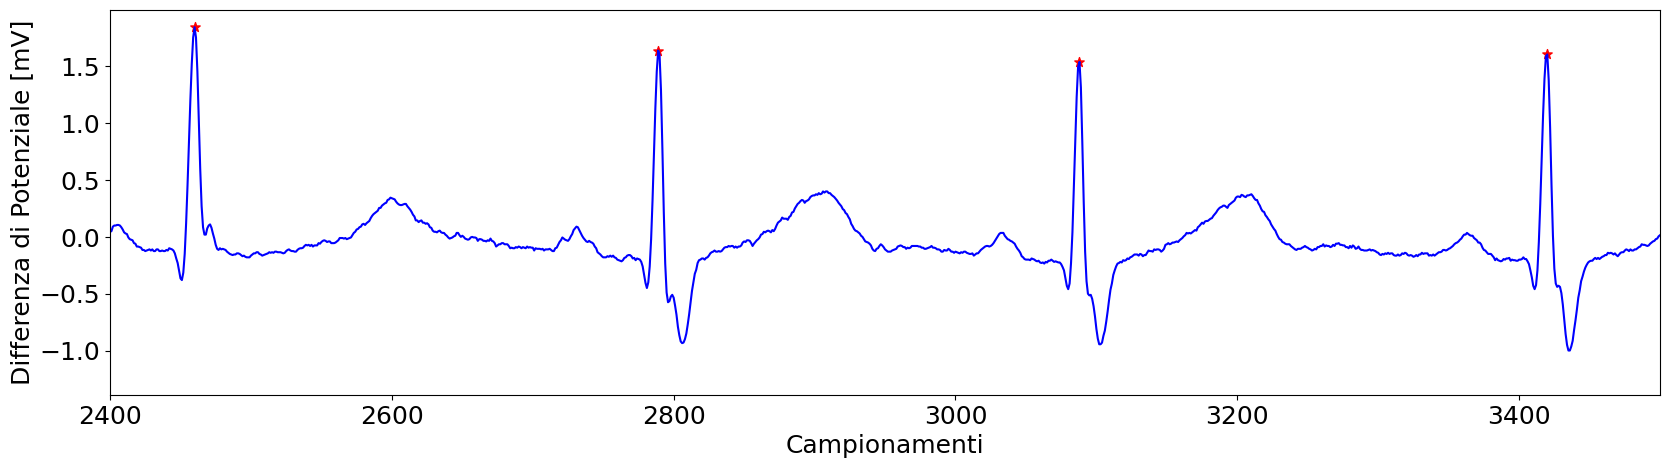

In [7]:
plt.figure(figsize = (20,5))
#plt.xticks(np.arange(0, len(clean_signal_RBBB_test)+1, 150))
plt.plot(test_RBBB_signal, color = 'blue')        
plt.xlim([2400,3500])
plt.scatter(detect_R(test_RBBB_signal) , test_RBBB_signal[detect_R(test_RBBB_signal)], color = 'red', s = 50, marker= '*')

plt.xlabel('Campionamenti')
plt.ylabel('Differenza di Potenziale [mV]')
plt.show()
#plt.savefig('R_decect.png')

In [8]:
RT_N_train = RT_interval(detect_R(train_N_signal),train_N_signal)
RT_RBBB_train = RT_interval(detect_R(train_RBBB_signal) ,train_RBBB_signal)
RT_pace_train = RT_interval(detect_R(train_pace_signal),train_pace_signal)

RT_N_test = RT_interval(detect_R(test_N_signal),test_N_signal)
RT_RBBB_test = RT_interval(detect_R(test_RBBB_signal),test_RBBB_signal)
RT_pace_test = RT_interval(detect_R(test_pace_signal),test_pace_signal)

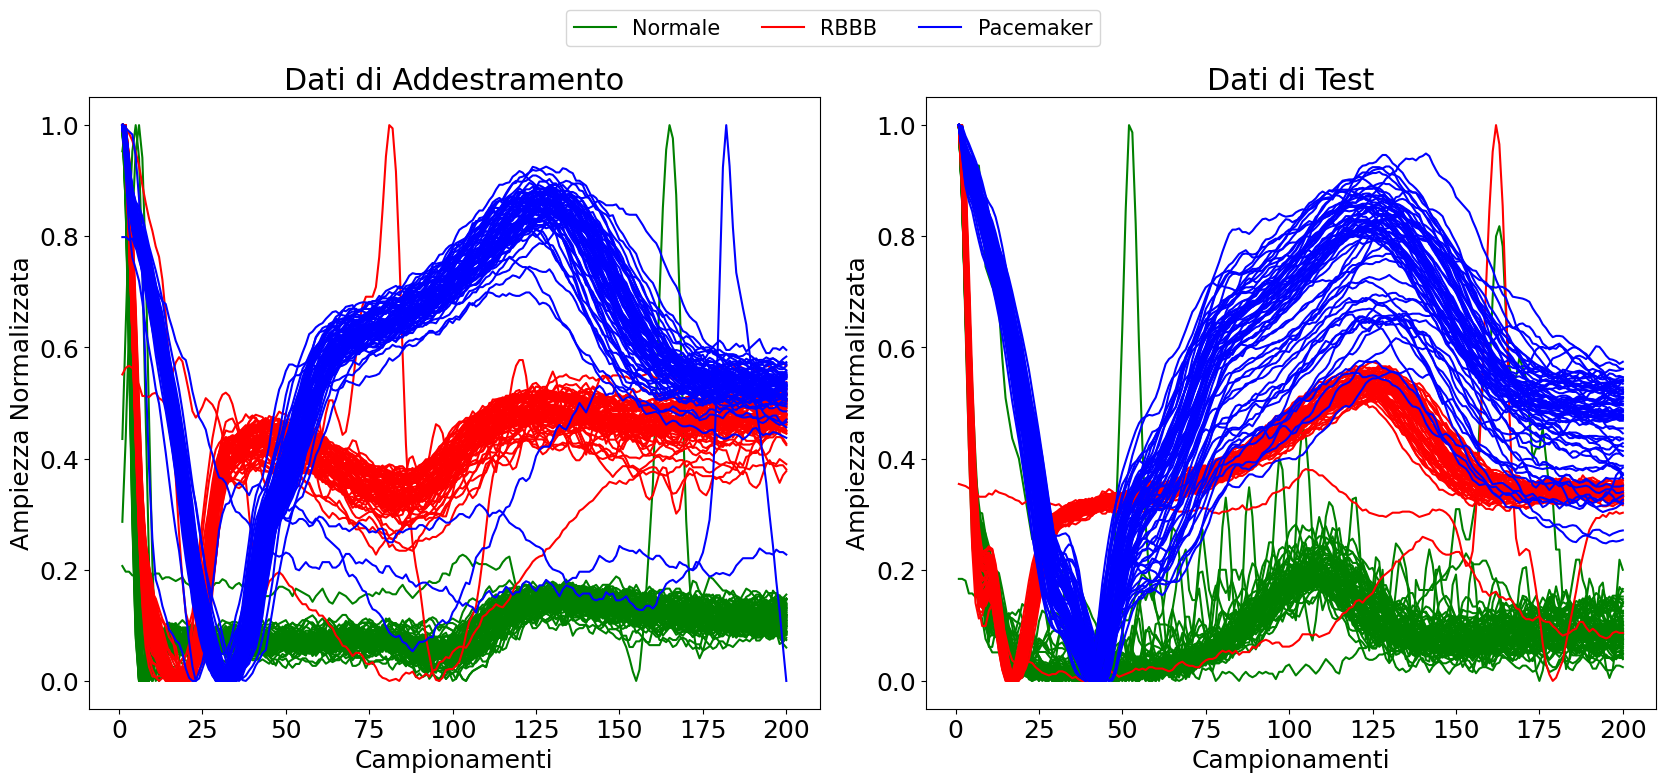

In [9]:

plt.figure(figsize=(17, 8))

# Subplot per i dati di addestramento
plt.subplot(1, 2, 1)
for i, segment in enumerate(RT_N_train):
    plt.plot(np.arange(len(segment)) + 1, segment, color='green', label='Normale' if i == 0 else "")
for i, segment in enumerate(RT_RBBB_train):
    plt.plot(np.arange(len(segment)) + 1, segment, color='red', label='RBBB' if i == 0 else "")
for i, segment in enumerate(RT_pace_train):
    plt.plot(np.arange(len(segment)) + 1, segment, color='blue', label='Pacemaker' if i == 0 else "")
plt.xlabel('Campionamenti')
plt.ylabel('Ampiezza Normalizzata')
plt.title('Dati di Addestramento')

# Subplot per i dati di test
plt.subplot(1, 2, 2)
for i, segment in enumerate(RT_N_test):
    plt.plot(np.arange(len(segment)) + 1, segment, color='green', label='Normale' if i == 0 else "")
for i, segment in enumerate(RT_RBBB_test):
    plt.plot(np.arange(len(segment)) + 1, segment, color='red', label='RBBB' if i == 0 else "")
for i, segment in enumerate(RT_pace_test):
    plt.plot(np.arange(len(segment)) + 1, segment, color='blue', label='Pacemaker' if i == 0 else "")
plt.xlabel('Campionamenti')
plt.ylabel('Ampiezza Normalizzata')
plt.title('Dati di Test')

#legenda unica per entrambi i grafici
handles, labels = plt.gca().get_legend_handles_labels()
plt.figlegend(handles, labels, loc='upper center', ncol=3, fontsize=15)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## ECG feature extraction using transferred deep learning 

In [10]:
# Crea un'immagine bianca di dimensioni 224*224.
# Mappa i valori del segnale ai pixel dell'immagine.
# Disegna una linea nera tra i punti successivi del segnale.

def signal_to_image(signal, img_size=224):
    """
    Trasforma un segnale normalizzato in un'immagine bianco-nero di dimensione 256x256x3.
    
    Parameters:
        signal (numpy.ndarray): Il segnale normalizzato (valori tra 0 e 1).
        img_size (int): La dimensione dell'immagine (img_size x img_size).
    
    Returns:
        numpy.ndarray: L'immagine risultante.
    """
    # una immagine bianca
    img = np.ones((img_size, img_size, 3), dtype=np.uint8) * 255
    
    # mappa i valori del segnale sull'immagine
    for i in range(len(signal) - 1):
        x1 = int(i / (len(signal) - 1) * (img_size - 1))
        y1 = int((1 - signal[i]) * (img_size - 1))
        x2 = int((i + 1) / (len(signal) - 1) * (img_size - 1))
        y2 = int((1 - signal[i + 1]) * (img_size - 1))
        
        # disegna una linea nera tra i punti
        img = cv2.line(img, (x1, y1), (x2, y2), (0, 0, 0), 1)
    
    return img



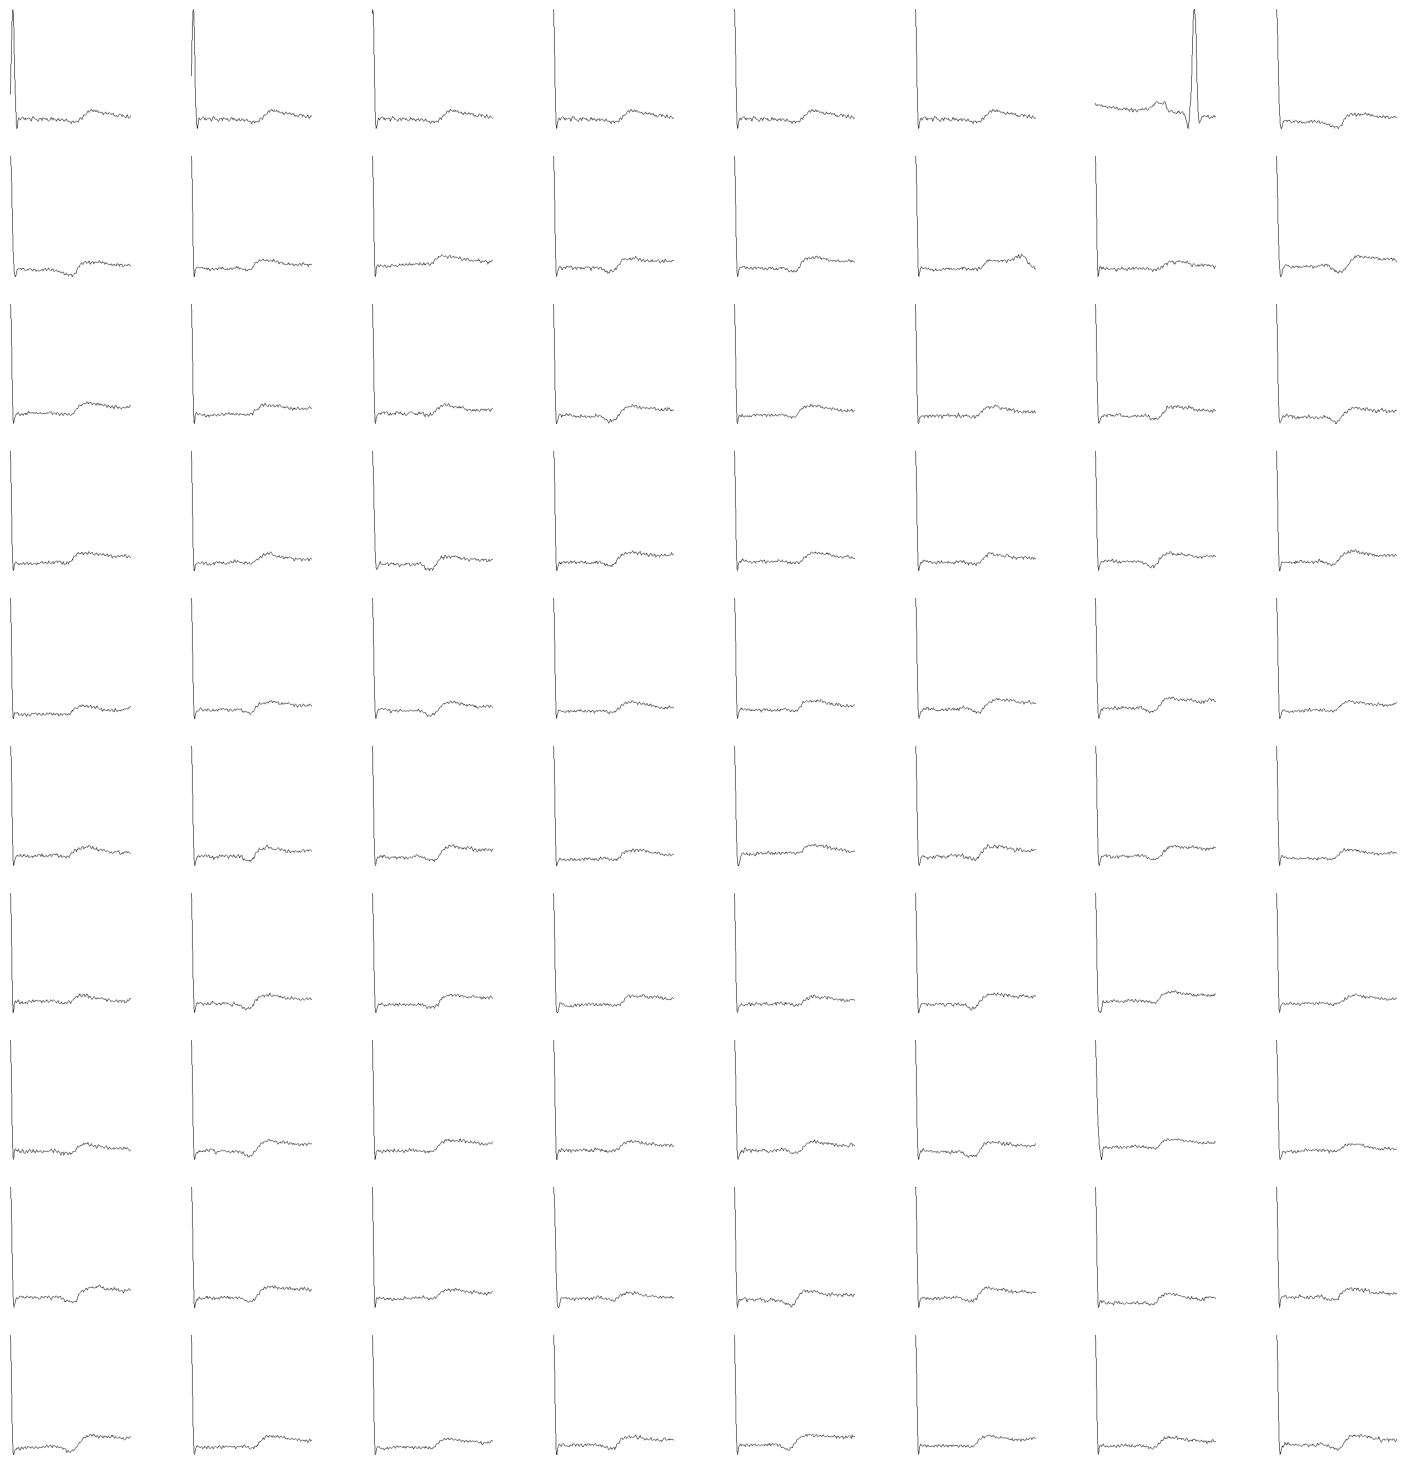

In [11]:
images = [signal_to_image(segment) for segment in RT_N_train]

fig, axs = plt.subplots(10, 8, figsize=(15, 15))
axs = axs.flatten()

for i, img in enumerate(images):

    axs[i].imshow(img)
    axs[i].axis('off')

plt.tight_layout()
plt.show()

In [12]:
#trasformo intervalli RT in immagini
images_N_train = [signal_to_image(segment) for segment in RT_N_train]
images_RBBB_train = [signal_to_image(segment) for segment in RT_RBBB_train]
images_pace_train = [signal_to_image(segment) for segment in RT_pace_train]

images_N_test = [signal_to_image(segment) for segment in RT_N_test]
images_RBBB_test = [signal_to_image(segment) for segment in RT_RBBB_test]
images_pace_test = [signal_to_image(segment) for segment in RT_pace_test]

In [13]:
#  modello AlexNet pre-allenato da pytorch
alexnet = models.alexnet(pretrained=True)

# trasformazioni per pre-processare le immagini
preprocess = transforms.Compose([
    transforms.ToTensor(), #trasformo in tensore PyTorch
     #normalizzo il tensore dell'immagine usando le medie e le deviazioni standard del dataset ImageNet
    #rappresentano i valori medi e di std dei pixel in ciascun canale (Rosso, Verde, Blu) sull'intero dataset di addestramento di ImageNet
    # in modo che i modelli pre-addestrati possano fare previsioni più accurate e convergere più velocemente 
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


#applica le trasformazioni definite precedentemente. Le immagini trasformate vengono poi raccolte in una lista di tensori, 
#che viene infine combinata in un unico tensore 4D usando torch.stack.def prepare_images(image_list):
def prepare_images(image_list):
    tensor_list = []
    for img in image_list:
        img = Image.fromarray(img)
        img = preprocess(img)
        tensor_list.append(img)
    return torch.stack(tensor_list)

# Funzione per ottenere gli output dei livelli fc6 e fc7
def get_fc6_fc7_outputs(tensor_images):
    #disattiva la registrazione del gradiente per risparmiare memoria e aumentare la velocità, poiché non sto addestrando il modello
    with torch.no_grad():
        #passa le immagini attraverso i livelli convolutivi di AlexNet
        features = alexnet.features(tensor_images)
        #appiattisco il tensore 
        features = torch.flatten(features, 1)
        #output fc6 e fc7
        fc6 = alexnet.classifier[1](features)
        fc7 = alexnet.classifier[4](fc6)
    return fc6, fc7


# Concatenazione dei dataset
def concatenate_and_process(image_sets_train, image_sets_test):

    train_tensors = [prepare_images(images) for images in image_sets_train]
    test_tensors = [prepare_images(images) for images in image_sets_test]
    
    concatenated_train_tensors = torch.cat(train_tensors)
    concatenated_test_tensors = torch.cat(test_tensors)
    
    #  output fc6 e fc7
    fc6_train, fc7_train = get_fc6_fc7_outputs(concatenated_train_tensors)
    fc6_test, fc7_test = get_fc6_fc7_outputs(concatenated_test_tensors)
    
    return (fc6_train, fc7_train), (fc6_test, fc7_test)

C:\Users\Utente\anaconda3\envs\tf_env\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Utente\anaconda3\envs\tf_env\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [14]:
alexnet

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [15]:
(fc6_train, fc7_train), (fc6_test, fc7_test) = concatenate_and_process(
    [images_N_train, images_RBBB_train, images_pace_train],
    [images_N_test, images_RBBB_test, images_pace_test]
)

labels_train = np.array([[1, 0, 0]] * len(images_N_train) + 
                        [[0, 1, 0]] * len(images_RBBB_train) + 
                        [[0, 0, 1]] * len(images_pace_train))

labels_test = np.array([[1, 0, 0]] * len(images_N_test) + 
                       [[0, 1, 0]] * len(images_RBBB_test) + 
                       [[0, 0, 1]] * len(images_pace_test))

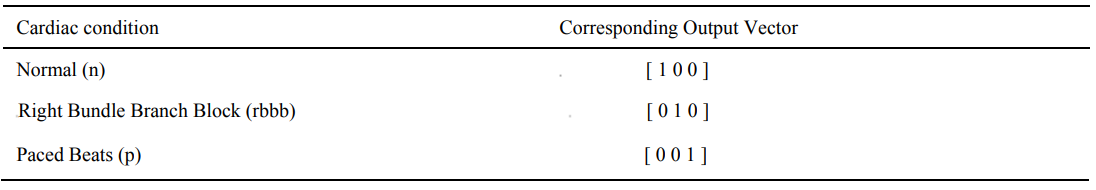

In [16]:
reduced_fc6_train, reduced_fc7_train = fc6_train, fc7_train
reduced_fc6_test, reduced_fc7_test = fc6_test, fc7_test

## ECG classification 


### PCA

In [278]:
def apply_pca(fc6, fc7, n_components=200):
    pca_fc6 = PCA(n_components=n_components)
    pca_fc7 = PCA(n_components=n_components)
    
    reduced_fc6 = pca_fc6.fit_transform(fc6)
    reduced_fc7 = pca_fc7.fit_transform(fc7)
    
    return reduced_fc6, reduced_fc7, pca_fc6, pca_fc7

# Riduco la dimensione dei vettori di caratteristiche
reduced_fc6_train, reduced_fc7_train, pca_fc6, pca_fc7 = apply_pca(fc6_train, fc7_train)

# Riduco anche i dati di test utilizzando i PCA addestrati sui dati di training
#La PCA calcola una trasformazione lineare basata sulla varianza dei dati di input. Se si addestra la PCA solo sui dati di training, 
#la trasformazione rifletterà la struttura dei dati di training. Applicare la stessa trasformazione ai dati di test garantisce che i 
# dati di test siano proiettati nello stesso spazio dei dati di training. Questo è cruciale per la coerenza, poiché il modello
# addestrato sui dati trasformati dovrebbe valutare i dati trasformati nello stesso modo.
reduced_fc6_test = pca_fc6.transform(fc6_test)
reduced_fc7_test = pca_fc7.transform(fc7_test)

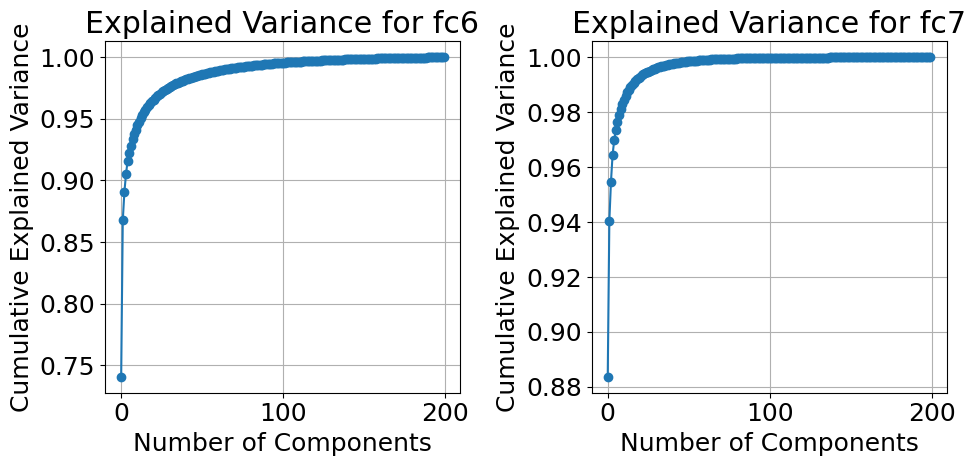

In [279]:
# percentuale di varianza spiegata
explained_variance_fc6 = np.cumsum(pca_fc6.explained_variance_ratio_)
explained_variance_fc7 = np.cumsum(pca_fc7.explained_variance_ratio_)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(explained_variance_fc6, marker='o')
plt.title('Explained Variance for fc6')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(explained_variance_fc7, marker='o')
plt.title('Explained Variance for fc7')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()

plt.tight_layout()
plt.show()

### Costruisco reti neurali FF

In [17]:
#metrica da valutare
def custom_accuracy(y_true, y_pred):
    return K.mean(K.sum(y_true * y_pred, axis=1))

def create_model(input_dim, hidden_neurons):
    model = Sequential([
        Dense(hidden_neurons, input_dim=input_dim, activation='relu'),
        Dense(3, activation='softmax')
    ])
    model.compile(optimizer='adam', 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy', custom_accuracy])
    return model


In [18]:
# variabili train e test per rete neurale samples degli intervalli RT senza DL extraction
RT_train = np.array(RT_N_train + RT_RBBB_train +RT_pace_train)
RT_test = np.array(RT_N_test + RT_RBBB_test +RT_pace_test)

#standardizzo prima di creare set di validazione
scaler_fc6 = StandardScaler()
scaler_fc7 = StandardScaler()
scaler_tst = StandardScaler()

reduced_fc6_train = scaler_fc6.fit_transform(reduced_fc6_train)
reduced_fc7_train = scaler_fc7.fit_transform(reduced_fc7_train)
RT_train = scaler_tst.fit_transform(RT_train)

reduced_fc6_test = scaler_fc6.transform(reduced_fc6_test)
reduced_fc7_test = scaler_fc7.transform(reduced_fc7_test)
RT_test = scaler_tst.transform(RT_test)

# crea set di validazione dal set di training
# fc6
train_features_fc6, val_features_fc6_train, train_labels_fc6, val_labels_train = train_test_split(
    reduced_fc6_train, labels_train, test_size=0.15, stratify=labels_train)

test_features_fc6, val_features_fc6_test, test_labels, val_labels_test = train_test_split(
    reduced_fc6_test, labels_test, test_size=0.15, stratify=labels_test)

val_features_fc6 = np.concatenate((val_features_fc6_test ,val_features_fc6_train), axis=0)
val_labels_fc6 = np.concatenate((val_labels_test ,val_labels_train), axis=0)

# fc7
train_features_fc7, val_features_fc7_train, train_labels_fc7, val_labels_train = train_test_split(
    reduced_fc7_train, labels_train, test_size=0.15, stratify=labels_train)

test_features_fc7, val_features_fc7_test, test_labels, val_labels_test = train_test_split(
    reduced_fc7_test, labels_test, test_size=0.15, stratify=labels_test)

val_features_fc7 = np.concatenate((val_features_fc7_test ,val_features_fc7_train), axis=0)
val_labels_fc7 = np.concatenate((val_labels_test ,val_labels_train), axis=0)

# tst
train_features_tst, val_features_tst_train, train_labels_tst, val_labels_train = train_test_split(
    RT_train, labels_train, test_size=0.15, stratify=labels_train)

test_features_tst, val_features_tst_test, test_labels, val_labels_test = train_test_split(
    RT_test, labels_test, test_size=0.15, stratify=labels_test)

val_features_tst = np.concatenate((val_features_tst_test ,val_features_tst_train), axis=0)
val_labels_tst = np.concatenate((val_labels_test ,val_labels_train), axis=0)

Valuto iperparametri con Hyperopt

- FC6

100%|███████████████████████████████████████████████| 30/30 [02:12<00:00,  4.43s/trial, best loss: -0.9852941036224365]
Best hyperparameters:  {'batch_size': 2, 'epochs': 2, 'hidden_neurons': 7}


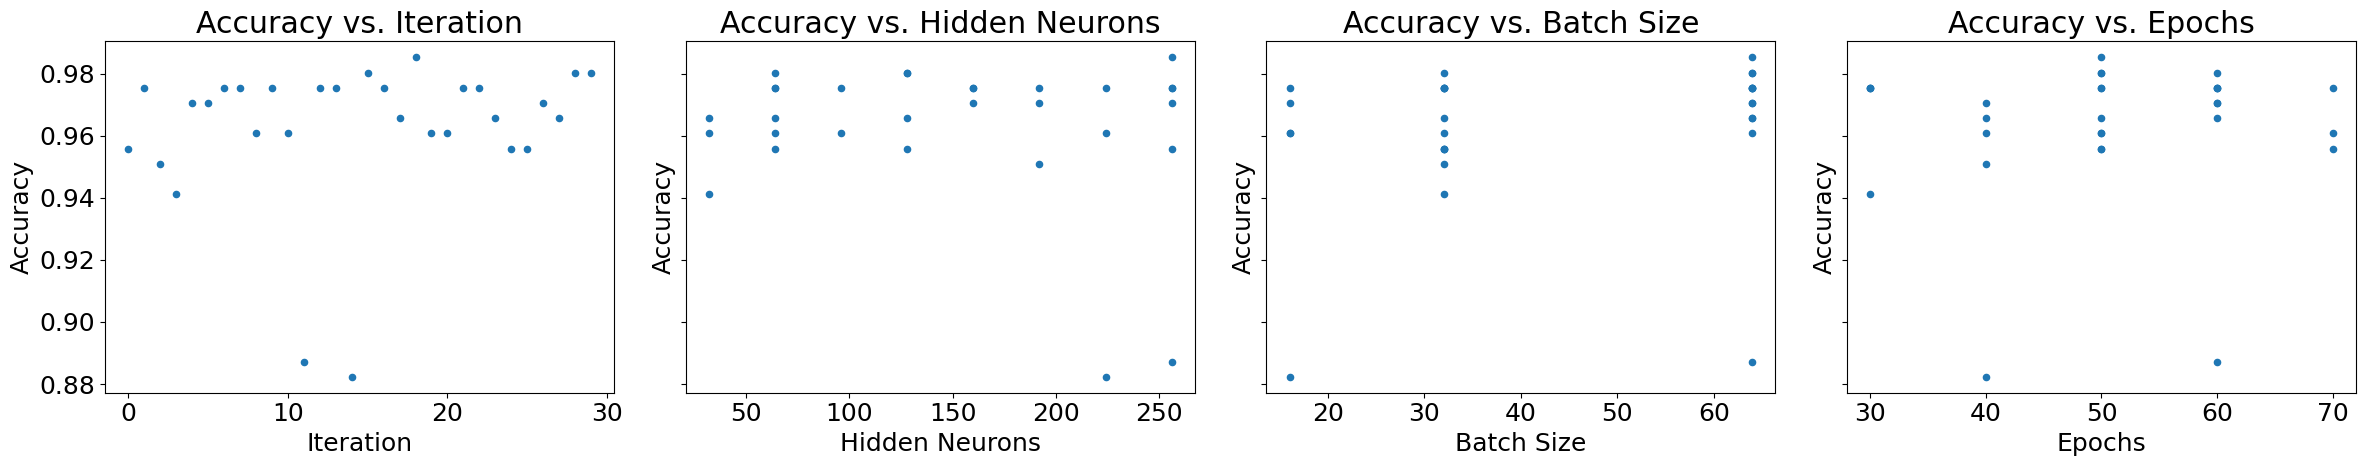

In [22]:
def train_model(train_features, train_labels, val_features, val_labels, params):
    model = create_model(input_dim=train_features.shape[1], 
                         hidden_neurons=params['hidden_neurons'])
    early_stopping = EarlyStopping(monitor='val_loss', patience=10)
    model.fit(train_features, train_labels, 
              epochs=int(params['epochs']), 
              batch_size=int(params['batch_size']), 
              validation_data=(val_features, val_labels), 
              callbacks=[early_stopping], 
              verbose=0,
              shuffle=True)
    return model

def test_model(model, test_features, test_labels):
    results = model.evaluate(test_features, test_labels, verbose=0)
    return results

def hyper_func(params):
    model = train_model(reduced_fc6_train, labels_train, val_features_fc6, val_labels_fc6, params)
    test_acc = test_model(model, reduced_fc6_test, labels_test)
    return {'loss': -test_acc[1], 'status': STATUS_OK}

search_space = {
    'hidden_neurons': hp.choice('hidden_neurons', np.arange(32, 257, 32)),
    'batch_size': hp.choice('batch_size', [16, 32, 64]),
    'epochs': hp.choice('epochs', [ 30, 40, 50, 60, 70])
}

trials = Trials()
best = fmin(hyper_func, search_space, algo=tpe.suggest, max_evals=30, trials=trials)
print("Best hyperparameters: ", best)


hidden_neurons_choices = np.arange(32, 257, 32)

_, (ax1, ax2, ax4, ax5) = plt.subplots(1, 4, sharey=True, figsize=(24, 5))

xs = [t['tid'] for t in trials.trials]
ys = [-t['result']['loss'] for t in trials.trials]
ax1.scatter(xs, ys, s=20)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy vs. Iteration')

xs = [hidden_neurons_choices[t['misc']['vals']['hidden_neurons'][0]] for t in trials.trials]
ys = [-t['result']['loss'] for t in trials.trials]
ax2.scatter(xs, ys, s=20)
ax2.set_xlabel('Hidden Neurons')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy vs. Hidden Neurons')

batch_size_choices = [16, 32,64]
xs = [batch_size_choices[t['misc']['vals']['batch_size'][0]] for t in trials.trials]
ys = [-t['result']['loss'] for t in trials.trials]
ax4.scatter(xs, ys, s=20)
ax4.set_xlabel('Batch Size')
ax4.set_ylabel('Accuracy')
ax4.set_title('Accuracy vs. Batch Size')

epochs_choices = [ 30, 40, 50, 60, 70]
xs = [epochs_choices[t['misc']['vals']['epochs'][0]] for t in trials.trials]
ys = [-t['result']['loss'] for t in trials.trials]
ax5.scatter(xs, ys, s=20)
ax5.set_xlabel('Epochs')
ax5.set_ylabel('Accuracy')
ax5.set_title('Accuracy vs. Epochs')

plt.tight_layout()
plt.show()

In [60]:
early_stop = EarlyStopping(monitor='val_loss', patience=10)

N_Fc6_model = create_model(reduced_fc6_train.shape[1], 64)

N_Fc6_model.fit(reduced_fc6_train, labels_train, epochs=70, batch_size=32, validation_data=(val_features_fc6, val_labels_fc6),shuffle=True,callbacks = [early_stop],verbose = 0)  

train_results = N_Fc6_model.evaluate(reduced_fc6_train, labels_train, verbose=0)
test_results = N_Fc6_model.evaluate(reduced_fc6_test, labels_test, verbose=0)
print('FC6')
print(f"Train Correct Recognition: {train_results[1]}, Train Accuracy: {train_results[2]}")
print(f"Test Correct Recognition: {test_results[1]}, Test Accuracy: {test_results[2]}")

FC6
Train Correct Recognition: 1.0, Train Accuracy: 0.9999904632568359
Test Correct Recognition: 0.9264705777168274, Test Accuracy: 0.9313103556632996


- FC7

100%|███████████████████████████████████████████████| 30/30 [01:32<00:00,  3.07s/trial, best loss: -0.9656862616539001]
Best hyperparameters:  {'batch_size': 0, 'epochs': 1, 'hidden_neurons': 3}


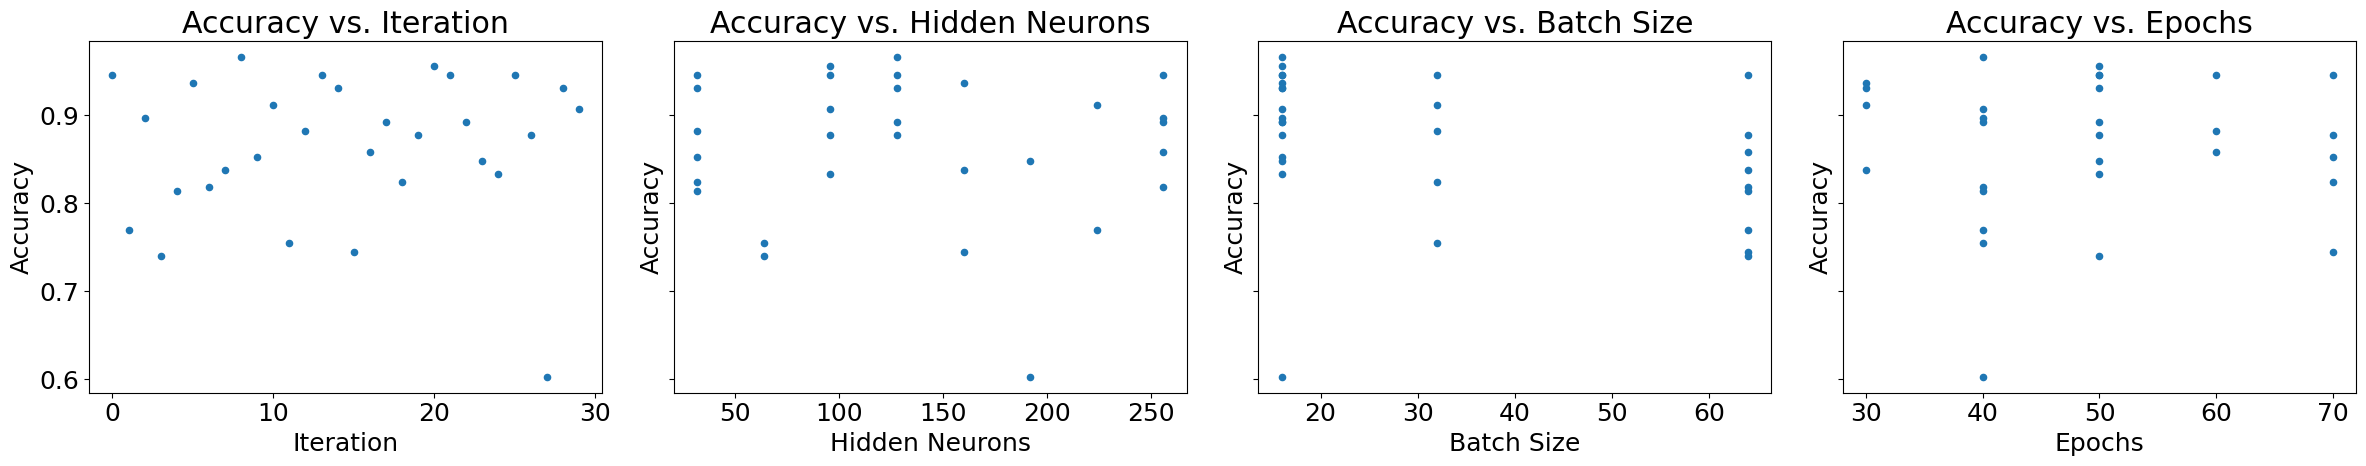

In [21]:
def hyper_func(params):
    model = train_model(reduced_fc7_train, labels_train, val_features_fc7, val_labels_fc7, params)
    test_acc = test_model(model, reduced_fc7_test, labels_test)
    return {'loss': -test_acc[1], 'status': STATUS_OK}

search_space = {
    'hidden_neurons': hp.choice('hidden_neurons', np.arange(32, 257, 32)),
    'batch_size': hp.choice('batch_size', [16, 32, 64]),
    'epochs': hp.choice('epochs', [ 30, 40, 50, 60, 70])
}

trials = Trials()
best = fmin(hyper_func, search_space, algo=tpe.suggest, max_evals=30, trials=trials)
print("Best hyperparameters: ", best)


_, (ax1, ax2, ax4, ax5) = plt.subplots(1, 4, sharey=True, figsize=(24, 5))

xs = [t['tid'] for t in trials.trials]
ys = [-t['result']['loss'] for t in trials.trials]
ax1.scatter(xs, ys, s=20)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy vs. Iteration')

xs = [hidden_neurons_choices[t['misc']['vals']['hidden_neurons'][0]] for t in trials.trials]
ys = [-t['result']['loss'] for t in trials.trials]
ax2.scatter(xs, ys, s=20)
ax2.set_xlabel('Hidden Neurons')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy vs. Hidden Neurons')

batch_size_choices = [16, 32,64]
xs = [batch_size_choices[t['misc']['vals']['batch_size'][0]] for t in trials.trials]
ys = [-t['result']['loss'] for t in trials.trials]
ax4.scatter(xs, ys, s=20)
ax4.set_xlabel('Batch Size')
ax4.set_ylabel('Accuracy')
ax4.set_title('Accuracy vs. Batch Size')

epochs_choices = [ 30, 40, 50, 60, 70]
xs = [epochs_choices[t['misc']['vals']['epochs'][0]] for t in trials.trials]
ys = [-t['result']['loss'] for t in trials.trials]
ax5.scatter(xs, ys, s=20)
ax5.set_xlabel('Epochs')
ax5.set_ylabel('Accuracy')
ax5.set_title('Accuracy vs. Epochs')

plt.tight_layout()
plt.show()

In [28]:
N_Fc7_model = create_model(reduced_fc7_train.shape[1], 128)

N_Fc7_model.fit(reduced_fc7_train, labels_train, epochs=60, batch_size=12, validation_data=(val_features_fc7, val_labels_fc7),shuffle=True,callbacks=[early_stop],verbose = 0)  

train_results = N_Fc7_model.evaluate(reduced_fc7_train, labels_train, verbose=0)
test_results = N_Fc7_model.evaluate(reduced_fc7_test, labels_test, verbose=0)
print('FC7')
print(f"Train Correct Recognition: {train_results[1]}, Train Accuracy: {train_results[2]}")
print(f"Test Correct Recognition: {test_results[1]}, Test Accuracy: {test_results[2]}")

FC7
Train Correct Recognition: 1.0, Train Accuracy: 0.9999731779098511
Test Correct Recognition: 0.936274528503418, Test Accuracy: 0.9435886740684509


- tst

100%|███████████████████████████████████████████████| 30/30 [02:07<00:00,  4.25s/trial, best loss: -0.9950980544090271]
Best hyperparameters:  {'batch_size': 2, 'epochs': 1, 'hidden_neurons': 4}


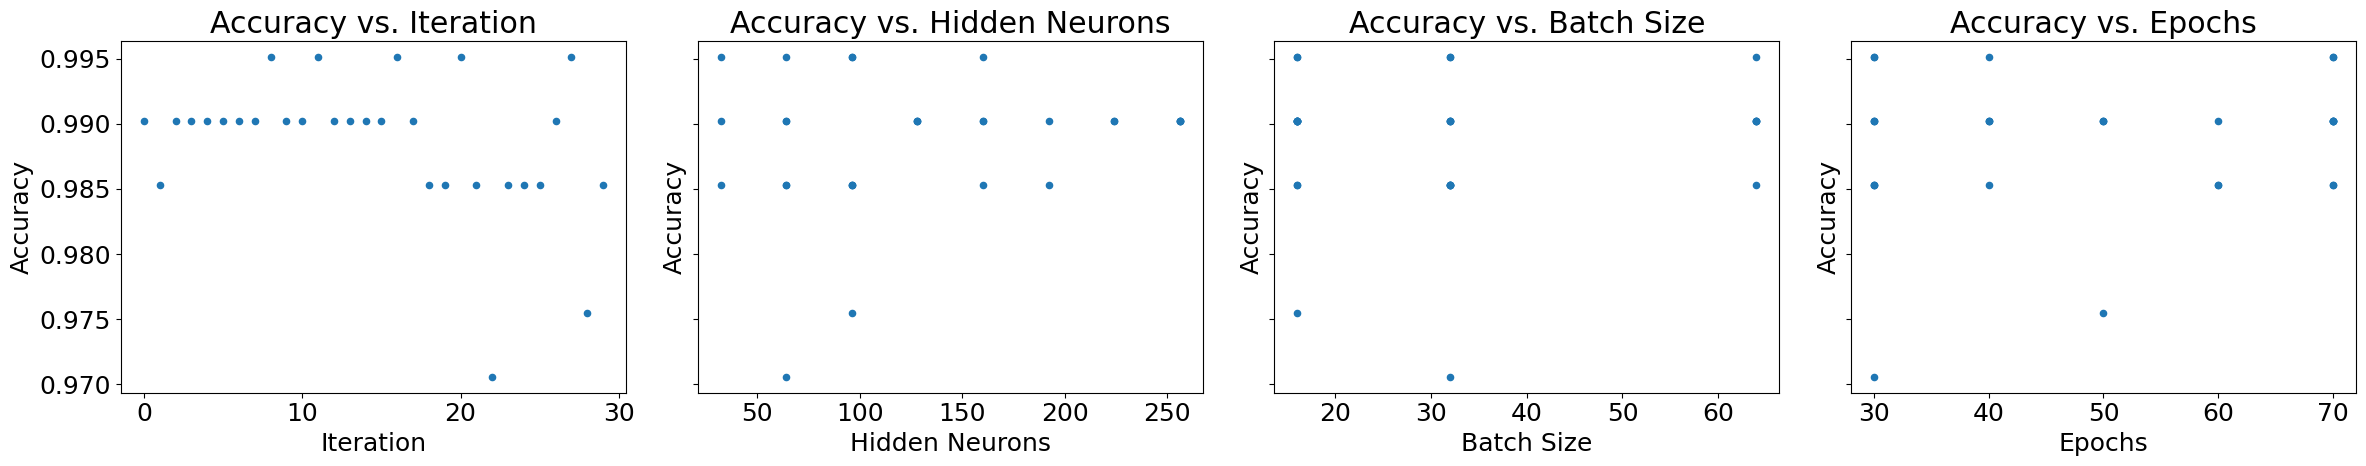

In [23]:
def hyper_func(params):
    model = train_model(RT_train, labels_train, val_features_tst, val_labels_tst, params)
    test_acc = test_model(model, RT_test, labels_test)
    return {'loss': -test_acc[1], 'status': STATUS_OK}

search_space = {
    'hidden_neurons': hp.choice('hidden_neurons', np.arange(32, 257, 32)),
    'batch_size': hp.choice('batch_size', [16, 32, 64]),
    'epochs': hp.choice('epochs', [ 30, 40, 50, 60, 70])
}

trials = Trials()
best = fmin(hyper_func, search_space, algo=tpe.suggest, max_evals=30, trials=trials)
print("Best hyperparameters: ", best)


_, (ax1, ax2, ax4, ax5) = plt.subplots(1, 4, sharey=True, figsize=(24, 5))

xs = [t['tid'] for t in trials.trials]
ys = [-t['result']['loss'] for t in trials.trials]
ax1.scatter(xs, ys, s=20)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy vs. Iteration')

xs = [hidden_neurons_choices[t['misc']['vals']['hidden_neurons'][0]] for t in trials.trials]
ys = [-t['result']['loss'] for t in trials.trials]
ax2.scatter(xs, ys, s=20)
ax2.set_xlabel('Hidden Neurons')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy vs. Hidden Neurons')

batch_size_choices = [16, 32,64]
xs = [batch_size_choices[t['misc']['vals']['batch_size'][0]] for t in trials.trials]
ys = [-t['result']['loss'] for t in trials.trials]
ax4.scatter(xs, ys, s=20)
ax4.set_xlabel('Batch Size')
ax4.set_ylabel('Accuracy')
ax4.set_title('Accuracy vs. Batch Size')

epochs_choices = [ 30, 40, 50, 60, 70]
xs = [epochs_choices[t['misc']['vals']['epochs'][0]] for t in trials.trials]
ys = [-t['result']['loss'] for t in trials.trials]
ax5.scatter(xs, ys, s=20)
ax5.set_xlabel('Epochs')
ax5.set_ylabel('Accuracy')
ax5.set_title('Accuracy vs. Epochs')

plt.tight_layout()
plt.show()

In [50]:
N_tst_model = create_model(RT_train.shape[1], 32)  # Input dimensioni 200 (segmenti R-T)

N_tst_model.fit(RT_train, labels_train, epochs=70, batch_size=32, validation_data=(val_features_tst, val_labels_tst),shuffle=True,callbacks=[early_stop], verbose=0)  

train_results = N_tst_model.evaluate(RT_train, labels_train, verbose=0)
test_results = N_tst_model.evaluate(RT_test, labels_test, verbose=0)
print('RT')
print(f"Train Correct Recognition: {train_results[1]}, Train Accuracy: {train_results[2]}")
print(f"Test Correct Recognition: {test_results[1]}, Test Accuracy: {test_results[2]}")

RT
Train Correct Recognition: 1.0, Train Accuracy: 0.9986634254455566
Test Correct Recognition: 0.970588207244873, Test Accuracy: 0.965442955493927


Risultati articolo

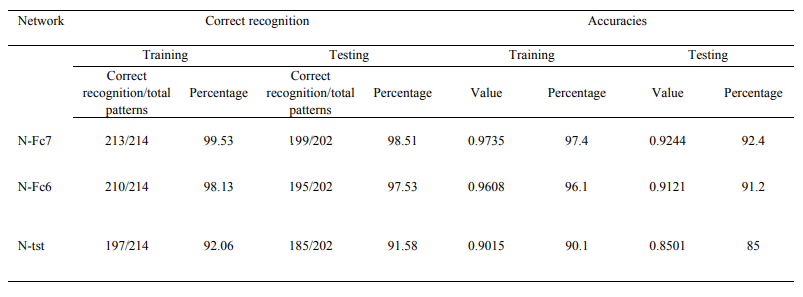